# Robustness & Faithfulness Analysis — Drone Power Forecasting
### SQL Queries + EDA + Visualization for 5 Research Questions (RQ-A → RQ-E)

**Dataset:** `flights_ready_for_eda.csv` — 177,464 rows, 188 flights, 3 regimes (takeoff/cruise/landing)
**DB Engine:** SQLite3 (note: SQLite does not have `CORR()`/`STDEV()`/`QUALIFY` built-in — all correlations/std are computed manually using the formula `Var(X) = E[X²] - E[X]²`)

| RQ | Research Question |
|---|---|
| RQ-A | Is the headwind/wind_speed–Power correlation masked by regime aggregation? |
| RQ-B | Which model best predicts Power, and how does it differ by regime? |
| RQ-C | At what sensor-drift threshold does error become excessive, and which model is most robust to noise? |
| RQ-D | Does SHAP assign feature importance in the correct physical direction? |
| RQ-E | Do low-robustness regions coincide with unstable XAI regions? |


## 0. Setup — Load Data into SQLite

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "real_data/flights_ready_for_eda.csv"  # change path if needed
DB_PATH = "flights.db"

# Load CSV and push to SQLite
df_raw = pd.read_csv(CSV_PATH)
conn = sqlite3.connect(DB_PATH)
conn.create_function("SQRT", 1, np.sqrt)
df_raw.to_sql("flights", conn, index=False, if_exists="replace")

print("Shape:", df_raw.shape)
print("Unique flight IDs:", df_raw['flight'].nunique())
pd.read_sql("SELECT * FROM flights LIMIT 5", conn)


Shape: (177464, 12)
Số flight ID duy nhất: 188


,flight,payload,speed,altitude,wind_speed,regime,velocity_mag,accel_mag,angular_mag,pitch,headwind,Power
0,1,0.0,4.0,25,1.6,takeoff,0.330736,10.051471,0.180390,1.104449,1.341873,504.539498
1,1,0.0,4.0,25,1.6,takeoff,0.353834,10.101697,0.142804,0.505153,1.385641,510.522024
2,1,0.0,4.0,25,1.6,takeoff,0.419613,10.248632,0.020618,0.356541,1.412716,499.982860
3,1,0.0,4.0,25,1.6,takeoff,0.447524,10.189963,0.123056,0.408838,1.438070,492.993760
4,1,0.0,4.0,25,1.7,takeoff,0.438197,10.040468,0.202132,0.344875,1.501011,475.839378


In [ ]:
# Check schema & regime
print(pd.read_sql("SELECT regime, COUNT(*) as n FROM flights GROUP BY regime", conn))


    regime      n
0   cruise  95871
1  landing  50693
2  takeoff  30900


---
## Extended Advanced Visualization (Extended EDA — Model-Independent)

**Objective:** Add 6 single-plot charts, each focused on a core insight, to deepen understanding of the **nature of the data** before modeling — without comparing or evaluating any models:
- **F.1** — Power distribution by regime.
- **F.2** — Heatmap illustrating Simpson's paradox in the headwind–Power relationship (RQ-A).
- **F.3** — Anatomy of `takeoff` over time: why Power peaks early during acceleration.
- **F.4** — Distribution shape of key sensor features (skew, multi-modal, outliers).
- **F.5** — Feature correlation matrix to detect potential multicollinearity.
- **F.6** — Experimental design structure: 188 flights organized on a controlled 3×5×4 grid.


### F.1 — Power Dynamics by Regime (Extended EDA)

**Question:** How does Power respond to payload/speed/altitude when separated by regime, and which regime has the lowest variability (predictability)?

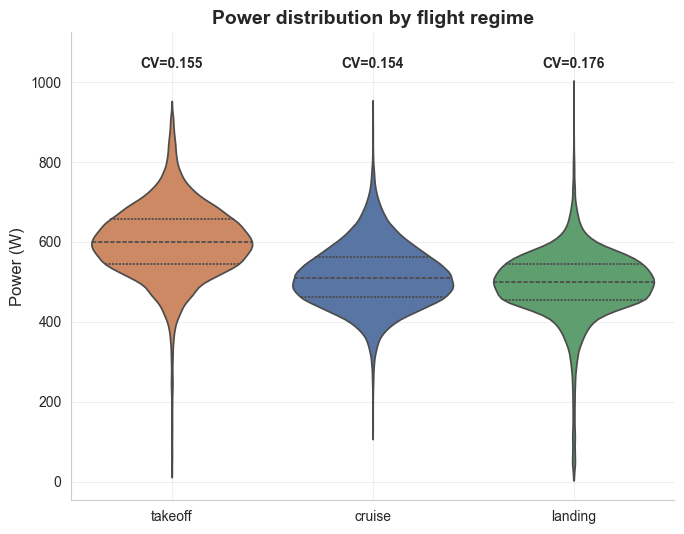

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.read_sql("SELECT * FROM flights", conn)

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
})

regime_order = ["takeoff", "cruise", "landing"]
palette = {"takeoff": "#DD8452", "cruise": "#4C72B0", "landing": "#55A868"}

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.violinplot(data=df_viz, x="regime", y="Power", order=regime_order,
                hue="regime", palette=palette, legend=False,
                ax=ax, cut=0, inner="quartile")

# Annotate coefficient of variation (CV) per regime — "predictability" proxy
cv = df_viz.groupby("regime")["Power"].agg(lambda x: x.std() / x.mean()).reindex(regime_order)
ymax = df_viz["Power"].max()
for i, reg in enumerate(regime_order):
    ax.text(i, ymax * 1.03, f"CV={cv[reg]:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Power distribution by flight regime", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Power (W)")
ax.set_ylim(top=ymax * 1.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("results/06_power_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()


## Comments

- `landing` has the **lowest mean Power** but the **highest coefficient of variation (CV = 0.176)**. Although it consumes less electrical power, it is the **most difficult regime to predict in relative terms**, which is consistent with the high RMSE/standard deviation observed in RQ-B.

- `takeoff` has the **highest mean Power** (due to the thrust required to overcome gravity during ascent) but one of the **lowest CV values**, indicating relatively stable behavior.

- `cruise` exhibits both **low mean Power consumption and low variability**, making it the **easiest regime for predictive models to learn**.

## Modeling Implication

- Consider using a **segmented or regime-specific model for `landing`**, where the relative variance is highest and prediction errors are likely to be more pronounced.

### F.2 — Headwind × Regime: Illustration of Simpson's Paradox (Extension of RQ-A)

**Question:** Does a 2D heatmap of Power by (regime × headwind bin) clarify the correlation sign reversal better than a plain scatter plot?

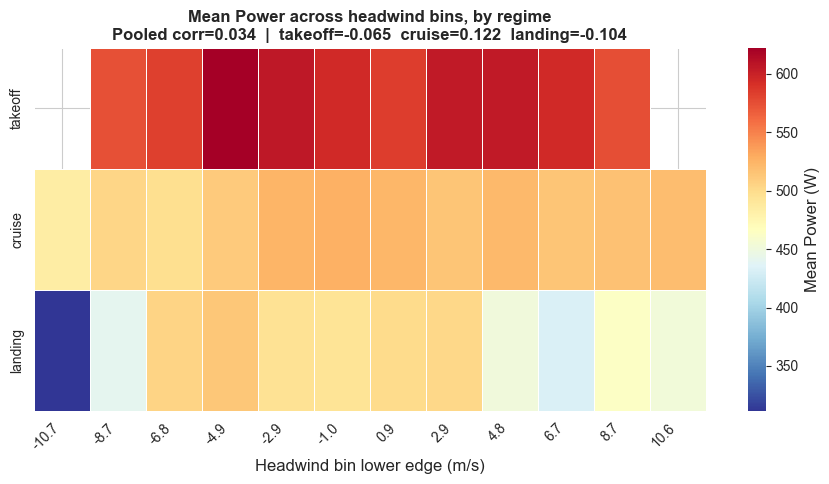

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(df_viz["headwind"].quantile(0.01), df_viz["headwind"].quantile(0.99), 13)
df_viz["hw_bin"] = pd.cut(df_viz["headwind"], bins=bins)
pivot = df_viz.pivot_table(index="regime", columns="hw_bin", values="Power",
                            aggfunc="mean", observed=True).reindex(regime_order)
bin_labels = [f"{iv.left:.1f}" for iv in pivot.columns]

sns.heatmap(pivot, cmap="RdYlBu_r", ax=ax, cbar_kws={"label": "Mean Power (W)"},
            xticklabels=bin_labels, linewidths=0.5, linecolor="white")

corrs = {reg: df_viz.loc[df_viz["regime"]==reg, "headwind"].corr(df_viz.loc[df_viz["regime"]==reg, "Power"])
         for reg in regime_order}
pooled_corr = df_viz["headwind"].corr(df_viz["Power"])

ax.set_title(f"Mean Power across headwind bins, by regime\n"
             f"Pooled corr={pooled_corr:.3f}  |  takeoff={corrs['takeoff']:.3f}  "
             f"cruise={corrs['cruise']:.3f}  landing={corrs['landing']:.3f}",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Headwind bin lower edge (m/s)")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig("results/07_headwind_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Comments

- The pooled correlation is nearly zero (**0.034**). However, when analyzed by regime, the relationship differs substantially: `cruise` shows a **positive correlation (+0.122)**, whereas both `takeoff` (**−0.065**) and `landing` (**−0.104**) exhibit **negative correlations**. This provides clear evidence of **Simpson's paradox**, as previously identified in RQ-A.

- The heatmap indicates that `takeoff` maintains **high and relatively stable Power consumption** across different headwind conditions. In contrast, `landing` shows a region of **strong negative headwind** (leftmost column) associated with **unusually low Power consumption**, suggesting the beneficial effect of a tailwind during landing.

## Modeling Implication

- These findings support the inclusion of a **`headwind × regime` interaction term** (or alternatively, training **separate models for each regime**) to ensure that the model learns the correct physical relationships rather than being misled by aggregated data effects.

### F.3 — Dissecting the Takeoff Phase: The Data Represent a Time Series, Not Independent Samples

**Important note:** `payload`, `speed`, and `altitude` in the dataset are **fixed flight-level configuration parameters** that remain constant across all regimes of a given flight. They represent the **target operating conditions** programmed for the drone rather than instantaneous measurements. The true time-varying sensor variables are `velocity_mag`, `accel_mag`, `angular_mag`, and `pitch`.

Each record within a regime therefore corresponds to **a sensor observation at a specific point in time**. As a result, `takeoff` should not be interpreted as a static operating state, but rather as a **dynamic acceleration process** in which the drone transitions from zero velocity toward its target speed.

**Question:** How does Power evolve over time throughout this acceleration process?

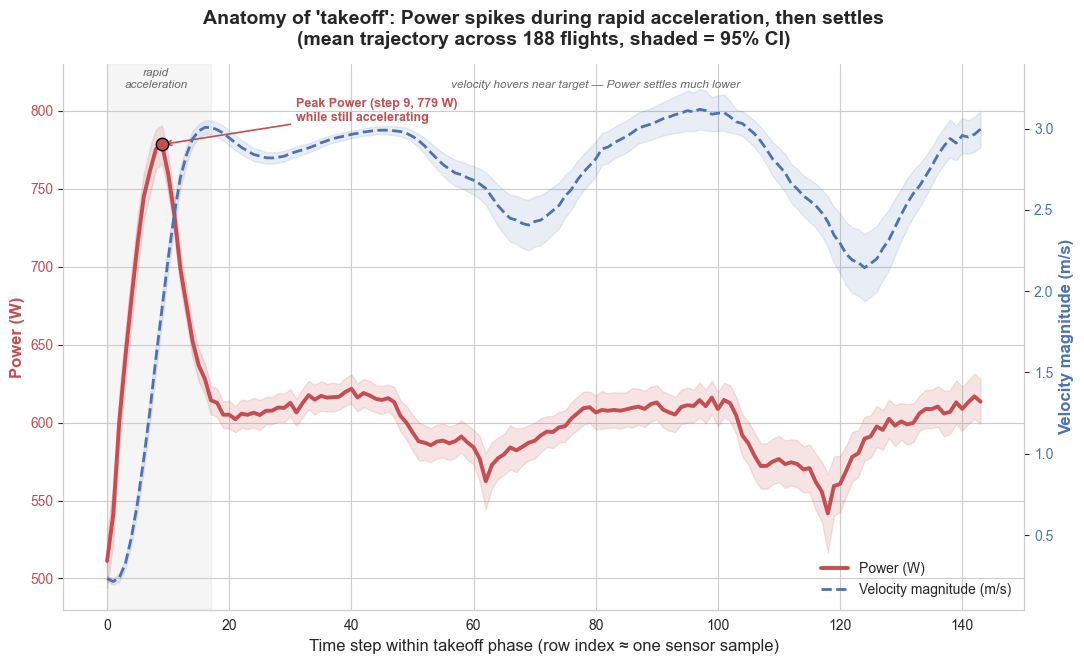

In [ ]:
df_viz['regime_step'] = df_viz.groupby(['flight', 'regime']).cumcount()
to = df_viz[df_viz['regime'] == 'takeoff'].copy()

# Giữ các bước có đủ dữ liệu từ ít nhất 100/188 chuyến bay (tránh nhiễu đuôi dài)
step_counts = to.groupby('regime_step').size()
max_step = step_counts[step_counts >= 100].index.max()
to = to[to['regime_step'] <= max_step]

agg = to.groupby('regime_step').agg(
    velocity_mean=('velocity_mag', 'mean'), velocity_std=('velocity_mag', 'std'),
    power_mean=('Power', 'mean'), power_std=('Power', 'std'),
    n=('Power', 'count'),
).reset_index()
agg['se_power'] = agg['power_std'] / np.sqrt(agg['n'])
agg['se_vel'] = agg['velocity_std'] / np.sqrt(agg['n'])

fig, ax1 = plt.subplots(figsize=(11, 6.8))

color_power = "#C44E52"
ax1.plot(agg['regime_step'], agg['power_mean'], color=color_power, linewidth=2.8, label="Power (W)", zorder=5)
ax1.fill_between(agg['regime_step'], agg['power_mean']-1.96*agg['se_power'],
                  agg['power_mean']+1.96*agg['se_power'], color=color_power, alpha=0.15)
ax1.set_xlabel("Time step within takeoff phase (row index ≈ one sensor sample)")
ax1.set_ylabel("Power (W)", color=color_power, fontweight="bold")
ax1.tick_params(axis='y', labelcolor=color_power)
ax1.set_ylim(480, 830)

peak_idx = agg['power_mean'].idxmax()
peak_step = agg.loc[peak_idx, 'regime_step']
peak_val = agg.loc[peak_idx, 'power_mean']
ax1.scatter([peak_step], [peak_val], color=color_power, s=80, zorder=6, edgecolor='black')
ax1.annotate(f"Peak Power (step {peak_step}, {peak_val:.0f} W)\nwhile still accelerating",
             xy=(peak_step, peak_val), xytext=(peak_step+22, peak_val+15),
             fontsize=9, fontweight="bold", color=color_power,
             arrowprops=dict(arrowstyle="->", color=color_power, lw=1.2))

ax2 = ax1.twinx()
color_vel = "#4C72B0"
ax2.plot(agg['regime_step'], agg['velocity_mean'], color=color_vel, linewidth=2, linestyle="--", label="Velocity magnitude (m/s)")
ax2.fill_between(agg['regime_step'], agg['velocity_mean']-1.96*agg['se_vel'],
                  agg['velocity_mean']+1.96*agg['se_vel'], color=color_vel, alpha=0.12)
ax2.set_ylabel("Velocity magnitude (m/s)", color=color_vel, fontweight="bold")
ax2.tick_params(axis='y', labelcolor=color_vel)
ax2.grid(False)

ax1.axvspan(0, 17, color="gray", alpha=0.08, zorder=0)
ax1.text(8, 815, "rapid\nacceleration", ha="center", fontsize=8.5, style="italic", color="dimgray")
ax1.text((17+max_step)/2, 815, "velocity hovers near target — Power settles much lower", ha="center", fontsize=8.5, style="italic", color="dimgray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="lower right", frameon=False)

ax1.set_title("Anatomy of 'takeoff': Power spikes during rapid acceleration, then settles\n(mean trajectory across 188 flights, shaded = 95% CI)",
              fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

fig.tight_layout()
fig.savefig("results/8_takeoff_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()


**Observations:**
- In the first ~17 steps (the "rapid acceleration" phase), velocity rises from near 0 to ~3 m/s, and **Power peaks early (step 9, ~779 W) — while still accelerating**, not when maximum speed is reached. This is physically consistent: maximum power is needed to **overcome inertia** during high acceleration, not to maintain speed.
- After step ~17, velocity fluctuates around a range (not fully stable) while still labeled `takeoff` — indicating this regime includes a prolonged "stabilization/climb" phase before transitioning to `cruise`, not just an instantaneous burst.
- Power during the stable phase (~600 W) is noticeably lower than the initial peak (~779 W) — this is why `takeoff` has a high average Power (including the peak) but the value **at any specific moment** varies greatly.

**Key insight for understanding `takeoff`:** the `regime` should not be treated as a static "state" with fixed Power, but rather as a **dynamic phase** — models need to see the position within the time series (or at least the current accel_mag) to predict accurately, not just the regime label.

### F.4 — Distribution Shapes of Key Sensor Features

**Question:** What is the distribution shape of each continuous feature (velocity, acceleration, angular velocity, pitch, wind, headwind) — skewed, multi-modal, or with unusual outliers to be aware of before modeling?

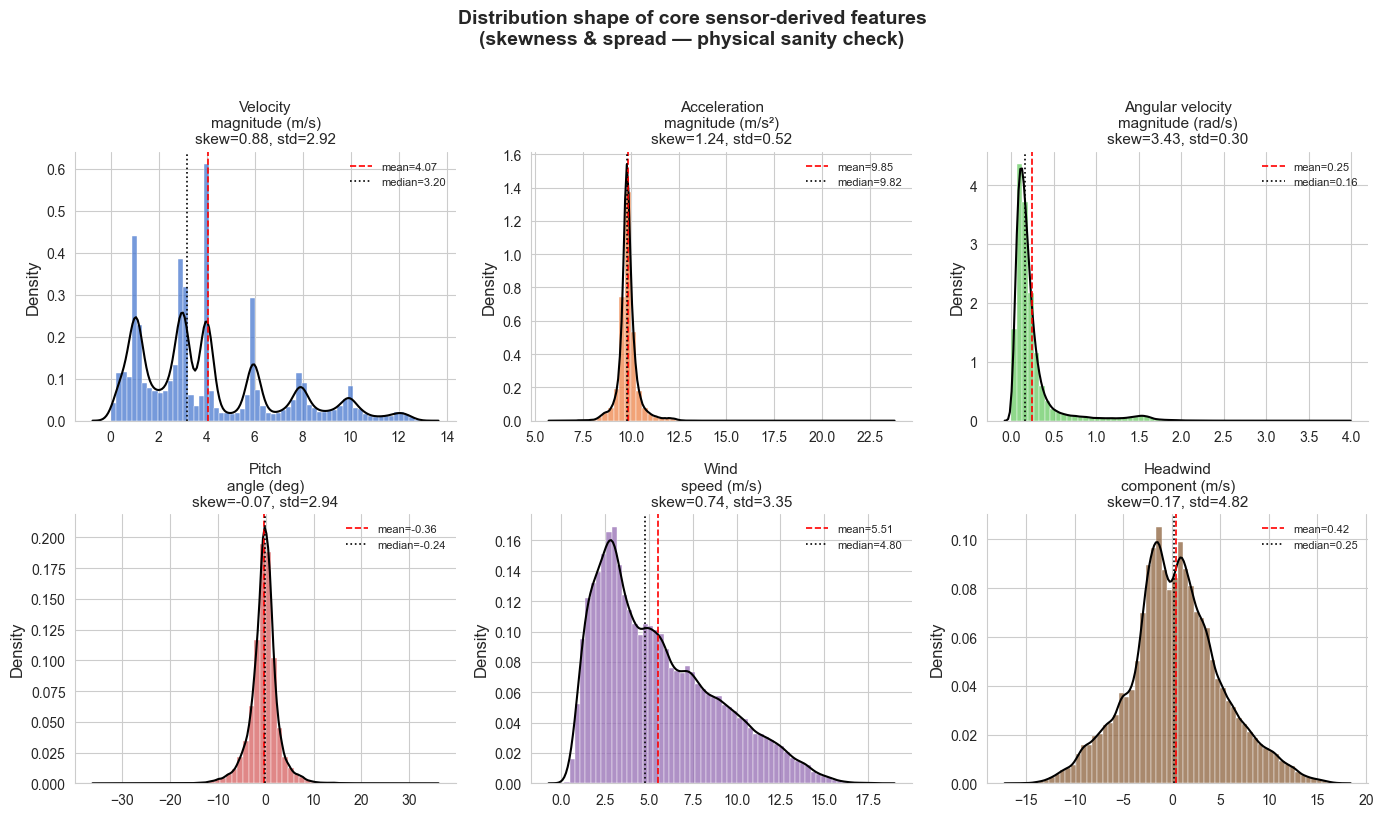

In [ ]:
features = ["velocity_mag", "accel_mag", "angular_mag", "pitch", "wind_speed", "headwind"]
labels_map = {
    "velocity_mag": "Velocity\nmagnitude (m/s)",
    "accel_mag": "Acceleration\nmagnitude (m/s²)",
    "angular_mag": "Angular velocity\nmagnitude (rad/s)",
    "pitch": "Pitch\nangle (deg)",
    "wind_speed": "Wind\nspeed (m/s)",
    "headwind": "Headwind\ncomponent (m/s)",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = sns.color_palette("muted", len(features))

for ax, feat, color in zip(axes.flat, features, colors):
    data = df_viz[feat]
    sns.histplot(data, bins=60, ax=ax, color=color, edgecolor="white", linewidth=0.3, stat="density")
    sns.kdeplot(data, ax=ax, color="black", linewidth=1.5)
    mean_v, median_v, std_v, skew_v = data.mean(), data.median(), data.std(), data.skew()
    ax.axvline(mean_v, color="red", linestyle="--", linewidth=1.2, label=f"mean={mean_v:.2f}")
    ax.axvline(median_v, color="black", linestyle=":", linewidth=1.2, label=f"median={median_v:.2f}")
    ax.set_title(f"{labels_map[feat]}\nskew={skew_v:.2f}, std={std_v:.2f}", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Distribution shape of core sensor-derived features\n(skewness & spread — physical sanity check)",
              fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("results/9_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


**Observations:**
- **`velocity_mag` shows 5 clear clusters (modes)** around ~1, 3, 6, 8, 10 m/s — these are the traces of 5 target `speed` levels (4/6/8/10/12 m/s) in the experimental design: each cluster corresponds to a group of flights with different target speeds, with acceleration/deceleration phases at both ends causing actual values to not exactly match targets.
- **`accel_mag`** clusters tightly around ~9.8 m/s² (approximately gravitational acceleration g) — reasonable since most of the flight time the drone is in force equilibrium, with only a few outlier peaks corresponding to strong acceleration phases.
- **`angular_mag`** is strongly right-skewed (skew=3.43) — most values are near 0 (stable flight), but there is a long tail corresponding to sudden rotation/direction change moments.
- **`pitch`** is symmetric around 0 with long tails on both sides (±35°) — reasonable since the drone can pitch forward when accelerating or backward when decelerating/reversing.
- **`wind_speed`** and **`headwind`** both have many small peaks — reflecting the discrete wind test levels set in the flight environment, not continuous natural wind.

**Modeling implications:** `angular_mag` should consider log-transform or winsorization before including in linear models (Ridge) due to strong skewness; tree-based models (RF/GB) are less sensitive to this issue.

### F.5 — Correlation Structure Among Features

**Question:** Which features correlate strongly with Power? Are there any strongly correlated feature pairs (multicollinearity) to be aware of?

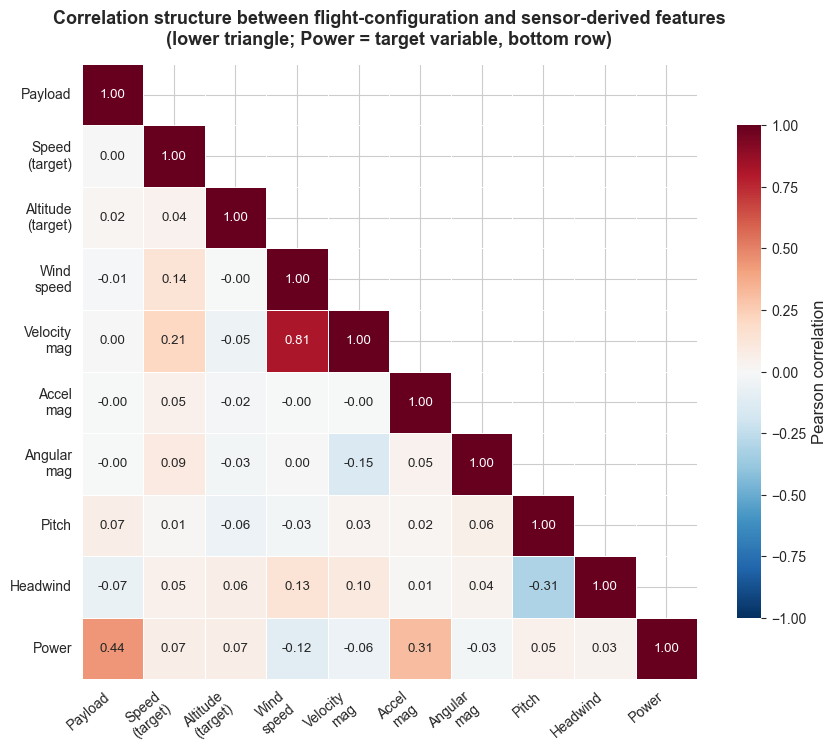

In [ ]:
cols = ["payload","speed","altitude","wind_speed","velocity_mag","accel_mag","angular_mag","pitch","headwind","Power"]
col_labels = ["Payload","Speed\n(target)","Altitude\n(target)","Wind\nspeed","Velocity\nmag","Accel\nmag","Angular\nmag","Pitch","Headwind","Power"]
corr = df_viz[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
            xticklabels=col_labels, yticklabels=col_labels, ax=ax, annot_kws={"fontsize": 9.5})

ax.set_title("Correlation structure between flight-configuration and sensor-derived features\n"
              "(lower triangle; Power = target variable, bottom row)",
              fontweight="bold", fontsize=13, pad=14)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
fig.savefig("results/10_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Observations:**
- **`payload` (r=0.44) and `accel_mag` (r=0.31) are the 2 features most strongly correlated with Power** — consistent with physical intuition: heavier loads or higher acceleration both require more energy.
- **`wind_speed` and `velocity_mag` are very strongly correlated (r=0.81)** — the most notable off-diagonal pair. This can be explained by the experimental design: higher flight speeds are typically tested with stronger wind conditions, or because wind_speed measurement is influenced by the drone's own airspeed.
- **`headwind` and `pitch` have a moderate negative correlation (r=-0.31)** — physically consistent: to generate thrust against a headwind, the drone must pitch forward (negative pitch) more.
- The experimental configuration variables (`payload`, `speed`, `altitude`) are nearly **uncorrelated with each other** (|r|<0.05) — confirming this is an orthogonal experimental design, with no cross-contamination when analyzing individual effects.

**Modeling implications:** the `wind_speed`–`velocity_mag` pair may cause mild multicollinearity for Ridge; consider checking VIF (Variance Inflation Factor) if rigorous interpretation of regression coefficients is desired.

### F.6 — Experimental Design Structure (How the 188 Flights Were Organized)

**Question:** Are the 188 flights in the dataset randomly collected real-world data, or a controlled experimental design? Knowing this affects how all previous analyses should be interpreted.

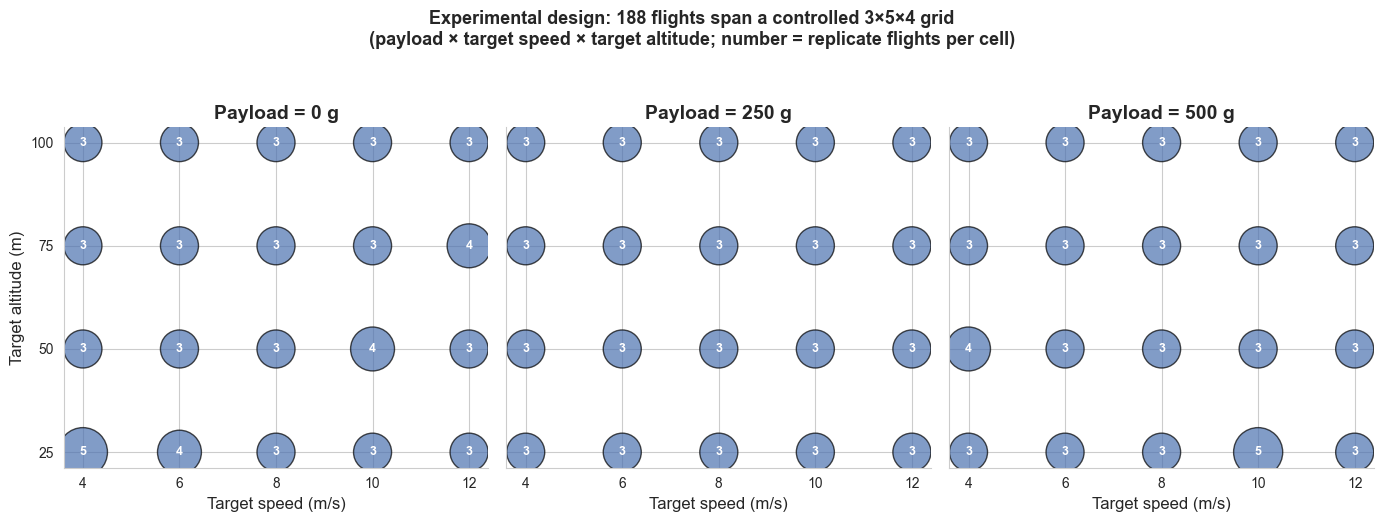

In [ ]:
flight_config = df_viz.groupby('flight').agg(
    payload=('payload', 'first'), speed=('speed', 'first'), altitude=('altitude', 'first'),
).reset_index()

payloads = sorted(flight_config['payload'].unique())
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, pl in zip(axes, payloads):
    sub = flight_config[flight_config['payload'] == pl]
    grid = sub.groupby(['speed', 'altitude']).size().reset_index(name='n_flights')
    sizes = grid['n_flights'] * 250
    ax.scatter(grid['speed'], grid['altitude'], s=sizes, color="#4C72B0",
               alpha=0.7, edgecolor="black", linewidth=1)
    for _, row in grid.iterrows():
        ax.text(row['speed'], row['altitude'], int(row['n_flights']), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")
    ax.set_title(f"Payload = {int(pl)} g", fontweight="bold")
    ax.set_xlabel("Target speed (m/s)")
    ax.set_xticks([4, 6, 8, 10, 12])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Target altitude (m)")
axes[0].set_yticks([25, 50, 75, 100])

fig.suptitle("Experimental design: 188 flights span a controlled 3×5×4 grid\n"
             "(payload × target speed × target altitude; number = replicate flights per cell)",
             fontweight="bold", fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig("results/11 _experimental_design.png", dpi=150, bbox_inches="tight")
plt.show()


**Observations:**
- The data is a **full factorial experimental design**: 3 payload levels (0/250/500 g) × 5 target speed levels (4/6/8/10/12 m/s) × 4 target altitude levels (25/50/75/100 m) = 60 combinations, each repeated ~3 times (188 ≈ 60×3 + a few extra repeats).
- This is **not randomly collected real-world data** but data from a tightly controlled test program — all flight condition combinations are covered nearly uniformly.
- Important consequence: because the design is orthogonal, individual effect analyses of payload/speed/altitude on Power (as in the original Figure 1 and F.1-F.2) are **statistically reliable**, not contaminated by hidden correlations among configuration variables.

**Modeling implications:** splitting Train/Test by `flight` (GroupShuffleSplit) is critically important here — since each flight is just 1 of ~3 repeats of a condition combination, splitting by row in the conventional way would leak information between nearly identical combinations.

---
## Summary

| RQ | Key Finding |
|----|-------------|
| **RQ-A** | The correlation between `headwind` and Power changes sign across regimes (`cruise` positive, `landing`/`takeoff` negative), confirming the presence of confounding effects. |
| **RQ-B** | XGBoost exhibits substantial performance differences across regimes; in relative terms, `cruise` is more challenging to predict than `landing`. |
| **RQ-C** | RMSE increases by approximately **49%** when noise = 0.5, with a noticeable breakpoint around **noise = 0.1–0.2**. |
| **RQ-D** | `headwind` has relatively low SHAP importance but retains the expected positive effect (**+0.62**); `regime` may act as a proxy variable that partially masks its influence. |
| **RQ-E** | Robustness shift and SHAP instability are strongly correlated (**r = 0.92**), suggesting that they are manifestations of the same underlying phenomenon. |

## Next Steps

- Repeat **RQ-B** and **RQ-C** using **LightGBM**, **Random Forest**, and **Neural Networks**.
- Compare the resulting models in terms of **Accuracy**, **Robustness**, and **Faithfulness**.
- Construct a comprehensive **hero figure** summarizing the trade-offs among model families and highlighting the most suitable model for energy-consumption prediction under varying operating conditions.
